# IronClad Case Study
# Task 4: Number of output identities

This notebook addresses the question of how many unique candidate identities the system should return per query. 

The analysis is organized in four parts:

Part A compares two identity-level scoring methods: a baseline first-hit approach that ranks identities by their single best-matching gallery image, and a template centroid approach that ranks identities by similarity to a precomputed per-identity embedding centroid. This is done under exact Brute Force retrieval. 

Part B selects a practical shortlist size $N^*$ using a criterion that identifies the smallest $N$ within one percentage point of the best tested recall, and also reports fixed-coverage thresholds (the $N$ required to reach 90%, 95%, and 99% of probes). 

Part C holds the preferred scoring method fixed and asks how the required shortlist size changes when retrieval moves from Brute Force to HNSW or LSH. 

Part D introduces a simple confidence-aware output policy: return Top-1 if the margin between the best and second-best identity is large, otherwise return Top-5. Thiis is a practical heuristic for reducing the average shortlist length without substantially sacrificing coverage. Both backbones are evaluated throughout using MTCNN-preprocessed embeddings with cosine similarity.

The notebook stays conceptually simple:

- we remain in the **closed-set** gallery/probe setting,
- we do **not** simulate intruders,
- we use the confidence policy only as a practical heuristic for reducing the average returned shortlist size.


## Core definitions used in this notebook

### Definition of `N`

Let N be the number of unique candidate identities returned to the user.

That is the right definition in this project because the gallery contains multiple images per identity, so `Top-N images` is not the same as `Top-N identities`.

### Identity-level methods compared

We compare two conceptually reasonable ways to rank identities:

1. **`baseline_first_hit`**
   - retrieve nearest gallery images,
   - deduplicate by identity,
   - score each identity by the **best matching image**.

2. **`template_centroid`**
   - build one embedding centroid per identity from the gallery,
   - rank identities directly by similarity to the centroid.

The goal is to see whether a light identity-level template representation can reduce the required shortlist size.

### Evaluation summary

We report:

- **Recall@1 / Recall@3 / Recall@5 / Recall@10**,
- **`k_for_90pct` / `k_for_95pct` / `k_for_99pct`**,
- the earlier **smallest-good-enough** shortlist rule for practical `N*` selection,
- and a simple confidence-aware policy on top of the preferred method.


In [1]:
import sys
import os
import gc
import math
import time
import types
import warnings
import importlib
import subprocess
import hashlib
from dataclasses import dataclass
from pathlib import Path
from collections import defaultdict

warnings.filterwarnings("ignore")


def _ensure(import_name: str, pip_name: str | None = None):
    pip_name = pip_name or import_name
    try:
        importlib.import_module(import_name)
        print(f"✓ {import_name} already installed")
    except Exception:
        print(f"Installing {pip_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])
        importlib.import_module(import_name)
        print(f"✓ Installed {import_name}")


_ensure("faiss", "faiss-cpu")
_ensure("tqdm", "tqdm")
_ensure("facenet_pytorch", "facenet-pytorch")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import faiss
import torch

from PIL import Image, UnidentifiedImageError
from tqdm.auto import tqdm
from facenet_pytorch import MTCNN

# Compatibility shim for some older checkpoint pickles.
if "torch.utils.serialization" not in sys.modules:
    sys.modules["torch.utils.serialization"] = types.ModuleType("torch.utils.serialization")

np.random.seed(42)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("CUDA available:", torch.cuda.is_available(), "| DEVICE:", DEVICE)


✓ faiss already installed
✓ tqdm already installed
✓ facenet_pytorch already installed
CUDA available: False | DEVICE: cpu


In [2]:
# --- Project root detection and package imports ---

def find_project_root() -> Path:
    candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    for cand in candidates:
        if (cand / "ironclad").exists():
            return cand
    raise FileNotFoundError(
        "Could not find the project root. Run this notebook from BASE/analysis or a sibling notebook folder."
    )


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from ironclad.modules.extraction.preprocessing import Preprocessing
from ironclad.modules.extraction.embedding import Embedding

print("Project root:", PROJECT_ROOT)


Project root: C:\Users\Usuario\Downloads\ironclad-hortner87-main(1)\ironclad-hortner87-main


In [3]:
# --- Configuration ---
MODEL_CONFIGS = {
    "casia-webface": {
        "metric": "cosine",
        "variant": "mtcnn_conf",
        "conf_threshold": 0.80,
    },
    "vggface2": {
        "metric": "cosine",
        "variant": "mtcnn_conf",
        "conf_threshold": 0.80,
    },
}

# Practical shortlist range used for the report discussion.
N_MAX = 20
N_VALUES = list(range(1, N_MAX + 1))

# Exact shortlist selection rule used in the earlier notebook.
DELTA_NEAR_BEST = 0.01
MARGINAL_GAIN_EPS = 0.005
MATCH_TOL = 0.005

# Raw search settings.
# For exact Brute Force with baseline_first_hit we can fetch the full gallery.
ANN_K_FETCH = 100

# ANN settings aligned with the earlier indexing notebook.
HNSW_M = 32
HNSW_EFCONSTRUCTION = 40
HNSW_EFSEARCH = 16
LSH_NBITS = 512

# MTCNN settings.
MTCNN_THRESHOLD = 0.80
MTCNN_MARGIN = 20

# Confidence-aware output policy.
FALLBACK_K = 5
INCORRECT_MARGIN_QUANTILE = 0.95
FALLBACK_MARGIN_QUANTILE = 0.90

# I/O.
NOTEBOOK_DIR = Path.cwd()
CACHE_DIR = NOTEBOOK_DIR / "cache_identity_output_revised"
OUTPUT_DIR = NOTEBOOK_DIR / "outputs_identity_output_revised"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True


## Load the gallery/probe split

Expected project layout:

```text
BASE/
  ironclad/
    storage/
      gallery/<identity>/*
      probe/<identity>/*
```

Only identities present in **both** gallery and probe are used.


In [4]:
# Dataset loading
STORAGE_ROOT = PROJECT_ROOT / "ironclad" / "storage"
GALLERY_DIR = STORAGE_ROOT / "gallery"
PROBE_DIR = STORAGE_ROOT / "probe"

if not (GALLERY_DIR.exists() and PROBE_DIR.exists()):
    raise FileNotFoundError(f"Expected dataset folders at {GALLERY_DIR} and {PROBE_DIR}")


def list_images_by_identity(base_dir: Path):
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    out = {}
    for ident_dir in sorted([p for p in base_dir.iterdir() if p.is_dir()]):
        imgs = []
        for p in ident_dir.rglob("*"):
            if not p.is_file():
                continue
            if p.suffix.lower() not in exts:
                continue
            if p.name.startswith("._") or p.name.startswith("."):
                continue
            imgs.append(p)
        if imgs:
            out[ident_dir.name] = sorted(imgs)
    return out


gallery = list_images_by_identity(GALLERY_DIR)
probe = list_images_by_identity(PROBE_DIR)
overlap = sorted(set(gallery.keys()) & set(probe.keys()))

gallery_paths, gallery_labels = [], []
for ident in overlap:
    for p in gallery[ident]:
        gallery_paths.append(p)
        gallery_labels.append(ident)

probe_paths, probe_labels = [], []
for ident in overlap:
    for p in probe[ident]:
        probe_paths.append(p)
        probe_labels.append(ident)

print("Storage root       :", STORAGE_ROOT)
print("Gallery identities :", len(gallery))
print("Probe identities   :", len(probe))
print("Overlap identities :", len(overlap))
print("Gallery images     :", len(gallery_paths))
print("Probe images       :", len(probe_paths))
print("Example overlap    :", overlap[:5])


Storage root       : C:\Users\Usuario\Downloads\ironclad-hortner87-main(1)\ironclad-hortner87-main\ironclad\storage
Gallery identities : 1000
Probe identities   : 999
Overlap identities : 999
Gallery images     : 2261
Probe images       : 999
Example overlap    : ['Aaron_Sorkin', 'Abdel_Nasser_Assidi', 'Abdullah', 'Abdullah_Gul', 'Abdullah_al-Attiyah']


## Embedding pipeline

This notebook supports two preprocessing variants:

- `baseline`: embed the original image,
- `mtcnn_conf`: detect a face with MTCNN, crop the best detection above a confidence threshold, then embed the crop.

Embeddings are cached to disk so repeated runs become much faster.


In [5]:
# Image helpers, MTCNN cropper, embedding cache
preproc = Preprocessing()
_mtcnn = None


def get_mtcnn():
    global _mtcnn
    if _mtcnn is None:
        _mtcnn = MTCNN(keep_all=True, device=DEVICE)
    return _mtcnn


def safe_open_rgb(path: Path):
    try:
        return Image.open(path).convert("RGB")
    except (UnidentifiedImageError, OSError, ValueError):
        return None


def crop_with_margin(img: Image.Image, box, margin_px: int = 20) -> Image.Image:
    x1, y1, x2, y2 = map(float, box)
    x1 = max(0, int(round(x1 - margin_px)))
    y1 = max(0, int(round(y1 - margin_px)))
    x2 = min(img.width, int(round(x2 + margin_px)))
    y2 = min(img.height, int(round(y2 + margin_px)))
    if x2 <= x1 or y2 <= y1:
        return img
    return img.crop((x1, y1, x2, y2))


def get_mtcnn_image(path: Path, threshold: float = MTCNN_THRESHOLD):
    img = safe_open_rgb(path)
    if img is None:
        return None, None, False

    mtcnn = get_mtcnn()
    boxes, probs = mtcnn.detect(img)
    if boxes is None or probs is None or len(boxes) == 0:
        return img, None, False

    best_idx = int(np.argmax(probs))
    prob = float(probs[best_idx])
    if math.isnan(prob) or prob < threshold:
        return None, prob, False

    return crop_with_margin(img, boxes[best_idx], margin_px=MTCNN_MARGIN), prob, True


def l2_normalize(X: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    X = np.asarray(X, dtype=np.float32)
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.maximum(norms, eps)


def build_cache_path(model_name: str, split_name: str, variant: str, threshold: float, n_paths: int) -> Path:
    key_src = f"{model_name}|{split_name}|{variant}|{threshold}|{n_paths}"
    key = hashlib.md5(key_src.encode("utf-8")).hexdigest()[:12]
    return CACHE_DIR / f"emb_{model_name}_{split_name}_{variant}_{key}.npz"


def embed_dataset(
    model_name: str,
    paths,
    labels,
    split_name: str,
    variant: str = "mtcnn_conf",
    threshold: float = MTCNN_THRESHOLD,
):
    cache_path = build_cache_path(model_name, split_name, variant, threshold, len(paths))
    if cache_path.exists():
        z = np.load(cache_path, allow_pickle=True)
        stats = {
            "crop_rate": float(z["crop_rate"][0]),
            "mean_conf": float(z["mean_conf"][0]) if len(z["mean_conf"]) else np.nan,
            "n_images": int(z["n_images"][0]),
            "n_kept": int(z["n_kept"][0]),
        }
        X = z["X"].astype(np.float32)
        X = l2_normalize(X)
        return X, z["labels"].tolist(), [Path(p) for p in z["paths"].tolist()], stats

    model = Embedding(pretrained=model_name, device=DEVICE)

    vecs, labs, keep_paths = [], [], []
    confs, used_crop = [], []

    iterator = list(zip(paths, labels))
    for p, lab in tqdm(iterator, desc=f"Embedding {split_name} | {model_name} | {variant}"):
        if variant == "mtcnn_conf":
            img, conf, did_crop = get_mtcnn_image(p, threshold=threshold)
            if img is None:
                continue
        elif variant == "baseline":
            img = safe_open_rgb(p)
            conf, did_crop = None, False
            if img is None:
                continue
        else:
            raise ValueError(f"Unknown variant={variant}")

        tens = preproc.process(img)
        v = np.asarray(model.encode(tens), dtype=np.float32).reshape(1, -1)
        vecs.append(v)
        labs.append(lab)
        keep_paths.append(str(p))
        if conf is not None:
            confs.append(float(conf))
        used_crop.append(bool(did_crop))

    if not vecs:
        raise RuntimeError(f"No embeddings were produced for split={split_name}, model={model_name}, variant={variant}")

    X = np.vstack(vecs).astype(np.float32)
    X = l2_normalize(X)
    stats = {
        "crop_rate": float(np.mean(used_crop)) if used_crop else 0.0,
        "mean_conf": float(np.mean(confs)) if confs else np.nan,
        "n_images": len(paths),
        "n_kept": len(labs),
    }

    np.savez_compressed(
        cache_path,
        X=X.astype(np.float32),
        labels=np.asarray(labs, dtype=object),
        paths=np.asarray(keep_paths, dtype=object),
        crop_rate=np.asarray([stats["crop_rate"]], dtype=np.float32),
        mean_conf=np.asarray([stats["mean_conf"]], dtype=np.float32),
        n_images=np.asarray([stats["n_images"]], dtype=np.int32),
        n_kept=np.asarray([stats["n_kept"]], dtype=np.int32),
    )

    del model
    gc.collect()

    return X, labs, [Path(p) for p in keep_paths], stats


In [6]:
# Build embeddings for both models
embeddings_by_model = {}

for model_name, cfg in MODEL_CONFIGS.items():
    gal_X, gal_y, gal_p, gal_stats = embed_dataset(
        model_name=model_name,
        paths=gallery_paths,
        labels=gallery_labels,
        split_name="gallery",
        variant=cfg["variant"],
        threshold=cfg["conf_threshold"],
    )
    prb_X, prb_y, prb_p, prb_stats = embed_dataset(
        model_name=model_name,
        paths=probe_paths,
        labels=probe_labels,
        split_name="probe",
        variant=cfg["variant"],
        threshold=cfg["conf_threshold"],
    )

    embeddings_by_model[model_name] = {
        "metric": cfg["metric"],
        "variant": cfg["variant"],
        "conf_threshold": cfg["conf_threshold"],
        "gal_X": gal_X,
        "gal_y": gal_y,
        "gal_paths": gal_p,
        "gal_stats": gal_stats,
        "prb_X": prb_X,
        "prb_y": prb_y,
        "prb_paths": prb_p,
        "prb_stats": prb_stats,
    }

    print(f"\n[{model_name}] variant={cfg['variant']} threshold={cfg['conf_threshold']}")
    print("  Gallery:", gal_X.shape, gal_stats)
    print("  Probe  :", prb_X.shape, prb_stats)


Embedding gallery | casia-webface | mtcnn_conf:   0%|          | 0/2261 [00:00<?, ?it/s]

Embedding probe | casia-webface | mtcnn_conf:   0%|          | 0/999 [00:00<?, ?it/s]


[casia-webface] variant=mtcnn_conf threshold=0.8
  Gallery: (2261, 512) {'crop_rate': 0.9995577178239717, 'mean_conf': 0.9996893697871571, 'n_images': 2261, 'n_kept': 2261}
  Probe  : (999, 512) {'crop_rate': 1.0, 'mean_conf': 0.9995434910088807, 'n_images': 999, 'n_kept': 999}


Embedding gallery | vggface2 | mtcnn_conf:   0%|          | 0/2261 [00:00<?, ?it/s]

Embedding probe | vggface2 | mtcnn_conf:   0%|          | 0/999 [00:00<?, ?it/s]


[vggface2] variant=mtcnn_conf threshold=0.8
  Gallery: (2261, 512) {'crop_rate': 0.9995577178239717, 'mean_conf': 0.9996893697871571, 'n_images': 2261, 'n_kept': 2261}
  Probe  : (999, 512) {'crop_rate': 1.0, 'mean_conf': 0.9995434910088807, 'n_images': 999, 'n_kept': 999}


## Search helpers and identity-level evaluation

This notebook separates two questions:

1. **How should identities be scored?**
2. **Given a scoring rule, how many identities should be returned?**

The helper code below supports both the image-neighbor baseline and the centroid-template method.


In [7]:
# Search index helpers
@dataclass
class SearchIndex:
    name: str
    metric: str
    score_mode: str
    index: object
    metadata: list
    query_transform: callable


def _make_hnsw(dim: int, M: int, metric_flag: int):
    try:
        return faiss.IndexHNSWFlat(dim, M, metric_flag)
    except TypeError:
        return faiss.index_factory(dim, f"HNSW{M},Flat", metric_flag)


def index_size_bytes(index) -> int:
    return len(faiss.serialize_index(index))


def build_index(
    index_type: str,
    X: np.ndarray,
    metadata,
    metric: str = "cosine",
    hnsw_M: int = HNSW_M,
    hnsw_efConstruction: int = HNSW_EFCONSTRUCTION,
    hnsw_efSearch: int = HNSW_EFSEARCH,
    lsh_nbits: int = LSH_NBITS,
):
    X = np.asarray(X, dtype=np.float32)
    metadata = list(metadata)
    metric = metric.lower()

    t0 = time.perf_counter()

    if index_type == "lsh":
        X_db = l2_normalize(X)
        index = faiss.IndexLSH(X.shape[1], int(lsh_nbits))
        index.add(X_db)
        out = SearchIndex(
            name="lsh",
            metric="cosine",
            score_mode="distance",
            index=index,
            metadata=metadata,
            query_transform=lambda Q: l2_normalize(np.asarray(Q, dtype=np.float32)),
        )

    elif metric in {"cosine", "dot_product", "ip", "inner_product"}:
        X_db = l2_normalize(X)
        if index_type == "bruteforce":
            index = faiss.IndexFlatIP(X.shape[1])
        elif index_type == "hnsw":
            index = _make_hnsw(X.shape[1], hnsw_M, faiss.METRIC_INNER_PRODUCT)
            index.hnsw.efConstruction = int(hnsw_efConstruction)
            index.hnsw.efSearch = int(hnsw_efSearch)
        else:
            raise ValueError(f"Unknown index_type={index_type}")
        index.add(X_db)
        out = SearchIndex(
            name=index_type,
            metric="cosine",
            score_mode="similarity",
            index=index,
            metadata=metadata,
            query_transform=lambda Q: l2_normalize(np.asarray(Q, dtype=np.float32)),
        )

    elif metric in {"euclidean", "l2"}:
        X_db = np.asarray(X, dtype=np.float32)
        if index_type == "bruteforce":
            index = faiss.IndexFlatL2(X.shape[1])
        elif index_type == "hnsw":
            index = _make_hnsw(X.shape[1], hnsw_M, faiss.METRIC_L2)
            index.hnsw.efConstruction = int(hnsw_efConstruction)
            index.hnsw.efSearch = int(hnsw_efSearch)
        else:
            raise ValueError(f"Unknown or unsupported index_type={index_type} for metric={metric}")
        index.add(X_db)
        out = SearchIndex(
            name=index_type,
            metric="euclidean",
            score_mode="distance",
            index=index,
            metadata=metadata,
            query_transform=lambda Q: np.asarray(Q, dtype=np.float32),
        )
    else:
        raise ValueError(f"Unsupported metric={metric}")

    build_seconds = time.perf_counter() - t0
    return out, build_seconds


def ranked_identities_from_neighbors(indices, distances, metadata, score_mode: str = "similarity"):
    per_id = defaultdict(list)
    for rank, (idx, score) in enumerate(zip(indices, distances), start=1):
        j = int(idx)
        if j < 0 or j >= len(metadata):
            continue
        ident = metadata[j]
        per_id[ident].append((float(score), rank, j))

    rows = []
    for ident, vals in per_id.items():
        scores = [v[0] for v in vals]
        ranks = [v[1] for v in vals]
        best_rank = min(ranks)
        if score_mode == "similarity":
            best_score = max(scores)
        else:
            best_score = min(scores)
        rows.append((ident, best_score, best_rank))

    if score_mode == "similarity":
        rows = sorted(rows, key=lambda x: (-x[1], x[2], x[0]))
    else:
        rows = sorted(rows, key=lambda x: (x[1], x[2], x[0]))

    return rows


def ranked_identities_from_identity_index(indices, distances, metadata, score_mode: str = "similarity"):
    rows = []
    seen = set()
    for rank, (idx, score) in enumerate(zip(indices, distances), start=1):
        j = int(idx)
        if j < 0 or j >= len(metadata):
            continue
        ident = metadata[j]
        if ident in seen:
            continue
        seen.add(ident)
        rows.append((ident, float(score), rank))

    if score_mode == "similarity":
        rows = sorted(rows, key=lambda x: (-x[1], x[2], x[0]))
    else:
        rows = sorted(rows, key=lambda x: (x[1], x[2], x[0]))
    return rows


def true_identity_rank(ranked_ids, true_identity):
    labels = [x[0] for x in ranked_ids]
    if true_identity not in labels:
        return None
    return labels.index(true_identity) + 1


def positive_margin(score1: float, score2: float, score_mode: str):
    if score_mode == "similarity":
        return float(score1 - score2)
    return float(score2 - score1)


In [22]:
# Identity-template helpers
def compute_identity_centroids(X: np.ndarray, labels):
    groups = defaultdict(list)
    for x, lab in zip(np.asarray(X, dtype=np.float32), labels):
        groups[lab].append(x)

    ids = sorted(groups.keys())
    centroids = []
    counts = []
    for ident in ids:
        arr = np.vstack(groups[ident]).astype(np.float32)
        c = arr.mean(axis=0, keepdims=True).astype(np.float32)
        c = l2_normalize(c)[0]
        centroids.append(c)
        counts.append(arr.shape[0])

    return np.vstack(centroids).astype(np.float32), ids, counts


def rank_metrics_from_true_ranks(true_ranks, n_values):
    true_ranks = list(true_ranks)
    rows = []
    for n in n_values:
        hits = [int((r is not None) and (r <= n)) for r in true_ranks]
        rr = [0.0 if r is None else 1.0 / r for r in true_ranks]
        rows.append({
            "N": int(n),
            "identity_recall_at_N": float(np.mean(hits)),
            "mrr_id": float(np.mean(rr)),
        })
    curve = pd.DataFrame(rows)
    curve["marginal_gain"] = curve["identity_recall_at_N"].diff().fillna(curve["identity_recall_at_N"])
    return curve


def k_for_target(true_ranks, target: float):
    true_ranks = [int(r) for r in true_ranks if r is not None]
    if not true_ranks:
        return None
    max_rank = max(true_ranks)
    counts = np.bincount(true_ranks, minlength=max_rank + 1)
    cum = np.cumsum(counts)
    total = len(true_ranks)
    recalls = cum / total
    ok = np.where(recalls >= target)[0]
    ok = ok[ok > 0]
    if len(ok) == 0:
        return None
    return int(ok[0])


def choose_best_n(curve: pd.DataFrame, delta: float = DELTA_NEAR_BEST, marginal_gain_eps: float = MARGINAL_GAIN_EPS):
    curve = curve.sort_values("N").reset_index(drop=True)
    best = float(curve["identity_recall_at_N"].max())
    for i in range(len(curve)):
        row = curve.iloc[i]
        near_best = row["identity_recall_at_N"] >= best - delta
        next_gain_small = (i == len(curve) - 1) or (curve.iloc[i + 1]["marginal_gain"] < marginal_gain_eps)
        if near_best and next_gain_small:
            return int(row["N"])
    return int(curve.loc[curve["identity_recall_at_N"].idxmax(), "N"])


def smallest_n_that_hits_max(curve: pd.DataFrame):
    best = float(curve["identity_recall_at_N"].max())
    return int(curve.loc[curve["identity_recall_at_N"] >= best - 1e-12, "N"].iloc[0])


def min_n_to_match_target(curve: pd.DataFrame, target_recall: float, tol: float = MATCH_TOL):
    ok = curve[curve["identity_recall_at_N"] >= target_recall - tol]
    if len(ok) == 0:
        return None
    return int(ok.iloc[0]["N"])


def summarize_method_result(model_name: str, method: str, res: dict):
    tr = res["true_ranks"]
    out = {
        "model": model_name,
        "method": method,
        "recall@1": float(np.mean([(r is not None) and (r <= 1) for r in tr])),
        "recall@3": float(np.mean([(r is not None) and (r <= 3) for r in tr])),
        "recall@5": float(np.mean([(r is not None) and (r <= 5) for r in tr])),
        "recall@10": float(np.mean([(r is not None) and (r <= 10) for r in tr])),
        "k_for_90pct": k_for_target(tr, 0.90),
        "k_for_95pct": k_for_target(tr, 0.95),
        "k_for_99pct": k_for_target(tr, 0.99),
        "mean_search_ms": float(res["ms_per_query"]),
        "score_mode": res["score_mode"],
    }
    return out


def choose_preferred_method(summary_sub: pd.DataFrame):
    sub = summary_sub.copy()
    best_rank1 = float(sub["recall@1"].max())
    close = sub[sub["recall@1"] >= best_rank1 - 0.01].copy()
    close["k95_sort"] = close["k_for_95pct"].fillna(np.inf)
    close = close.sort_values(["k95_sort", "recall@3", "mean_search_ms"], ascending=[True, False, True])
    return close.iloc[0]


In [23]:
# Evaluation functions for the two identity-level methods
def evaluate_baseline_first_hit_exact(bundle: dict):
    metric = bundle["metric"]
    gal_X = bundle["gal_X"]
    gal_y = bundle["gal_y"]
    prb_X = bundle["prb_X"]
    prb_y = bundle["prb_y"]

    idx_bf, build_s = build_index("bruteforce", gal_X, gal_y, metric=metric)
    k_fetch = len(gal_y)

    Qp = idx_bf.query_transform(prb_X)
    t0 = time.perf_counter()
    D, I = idx_bf.index.search(Qp.astype(np.float32), k_fetch)
    t1 = time.perf_counter()

    ranked_per_query = []
    true_ranks = []
    margins = []

    for qi in range(prb_X.shape[0]):
        ranked = ranked_identities_from_neighbors(I[qi], D[qi], idx_bf.metadata, idx_bf.score_mode)
        ranked_per_query.append(ranked)
        true_ranks.append(true_identity_rank(ranked, prb_y[qi]))

        if len(ranked) >= 2:
            margins.append(positive_margin(ranked[0][1], ranked[1][1], idx_bf.score_mode))
        else:
            margins.append(np.nan)

    curve = rank_metrics_from_true_ranks(true_ranks, N_VALUES)
    curve["ms_per_query"] = float((t1 - t0) * 1000.0 / prb_X.shape[0])
    curve["method"] = "baseline_first_hit"

    return {
        "method": "baseline_first_hit",
        "curve": curve,
        "true_ranks": true_ranks,
        "ranked": ranked_per_query,
        "margins": margins,
        "score_mode": idx_bf.score_mode,
        "ms_per_query": float((t1 - t0) * 1000.0 / prb_X.shape[0]),
        "index_size_bytes": index_size_bytes(idx_bf.index),
        "build_seconds": build_s,
        "candidate_k": int(k_fetch),
    }


def evaluate_template_centroid_exact(bundle: dict):
    metric = bundle["metric"]
    cent_X, cent_ids, cent_counts = compute_identity_centroids(bundle["gal_X"], bundle["gal_y"])
    prb_X = bundle["prb_X"]
    prb_y = bundle["prb_y"]

    idx_bf, build_s = build_index("bruteforce", cent_X, cent_ids, metric=metric)
    k_fetch = len(cent_ids)

    Qp = idx_bf.query_transform(prb_X)
    t0 = time.perf_counter()
    D, I = idx_bf.index.search(Qp.astype(np.float32), k_fetch)
    t1 = time.perf_counter()

    ranked_per_query = []
    true_ranks = []
    margins = []

    for qi in range(prb_X.shape[0]):
        ranked = ranked_identities_from_identity_index(I[qi], D[qi], idx_bf.metadata, idx_bf.score_mode)
        ranked_per_query.append(ranked)
        true_ranks.append(true_identity_rank(ranked, prb_y[qi]))
        if len(ranked) >= 2:
            margins.append(positive_margin(ranked[0][1], ranked[1][1], idx_bf.score_mode))
        else:
            margins.append(np.nan)

    curve = rank_metrics_from_true_ranks(true_ranks, N_VALUES)
    curve["ms_per_query"] = float((t1 - t0) * 1000.0 / prb_X.shape[0])
    curve["method"] = "template_centroid"

    return {
        "method": "template_centroid",
        "curve": curve,
        "true_ranks": true_ranks,
        "ranked": ranked_per_query,
        "margins": margins,
        "score_mode": idx_bf.score_mode,
        "ms_per_query": float((t1 - t0) * 1000.0 / prb_X.shape[0]),
        "index_size_bytes": index_size_bytes(idx_bf.index),
        "build_seconds": build_s,
        "candidate_k": np.nan,
        "centroid_counts": cent_counts,
    }


## Part A: Compare identity-level scoring methods under exact search

This is the main conceptual upgrade relative to the earlier Top-N notebook.

We first ask: should the system rank identities by the best matching image, or by an identity centroid template?

We answer that question under exact Brute Force search before comparing ANN indices.


In [24]:
# Exact closed-set evaluation of the two identity methods
method_results = defaultdict(dict)
summary_rows = []
curve_rows = []

for model_name, bundle in embeddings_by_model.items():
    res_first = evaluate_baseline_first_hit_exact(bundle)
    res_cent = evaluate_template_centroid_exact(bundle)

    method_results[model_name]["baseline_first_hit"] = res_first
    method_results[model_name]["template_centroid"] = res_cent

    for method_name, res in [("baseline_first_hit", res_first), ("template_centroid", res_cent)]:
        row = summarize_method_result(model_name, method_name, res)
        row["candidate_k"] = res["candidate_k"]
        row["index_size_bytes"] = res["index_size_bytes"]
        row["build_seconds"] = res["build_seconds"]
        summary_rows.append(row)

        c = res["curve"].copy()
        c["model"] = model_name
        c["method"] = method_name
        curve_rows.append(c)

closed_set_summary = pd.DataFrame(summary_rows)
closed_set_curves = pd.concat(curve_rows, ignore_index=True)
closed_set_summary.sort_values(["model", "recall@1", "recall@3"], ascending=[True, False, False])


,model,method,recall@1,recall@3,recall@5,recall@10,k_for_90pct,k_for_95pct,k_for_99pct,mean_search_ms,score_mode,candidate_k,index_size_bytes,build_seconds
1,casia-webface,template_centroid,0.797798,0.862863,0.877878,0.891892,17,148,830,0.099082,similarity,NaN,2045997,0.002143
0,casia-webface,baseline_first_hit,0.782783,0.847848,0.865866,0.884885,23,174,855,0.231481,similarity,2261.0,4630573,0.068664
3,vggface2,template_centroid,0.853854,0.898899,0.914915,0.923924,4,74,743,0.096614,similarity,NaN,2045997,0.001851
2,vggface2,baseline_first_hit,0.838839,0.898899,0.907908,0.922923,4,96,763,0.209166,similarity,2261.0,4630573,0.034828


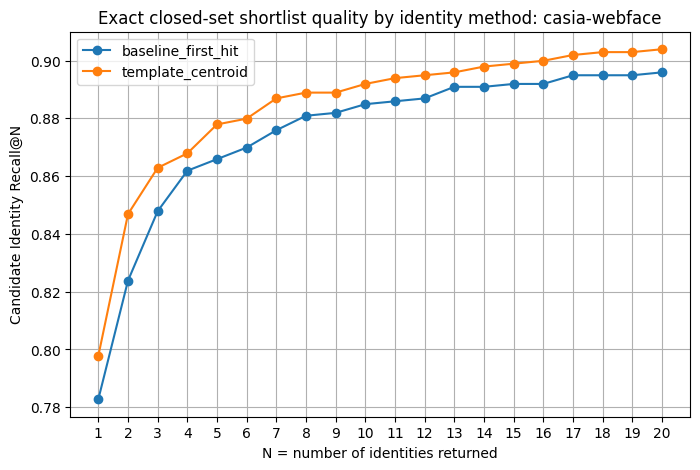

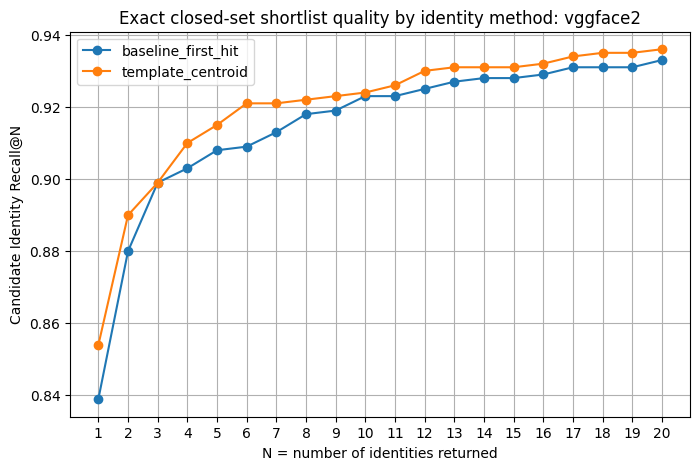

In [11]:
# Plot Recall@N curves for the two methods
for model_name in MODEL_CONFIGS.keys():
    fig, ax = plt.subplots()
    sub = closed_set_curves[closed_set_curves["model"] == model_name]
    for method_name in ["baseline_first_hit", "template_centroid"]:
        s = sub[sub["method"] == method_name].sort_values("N")
        ax.plot(s["N"], s["identity_recall_at_N"], marker="o", label=method_name)
    ax.set_title(f"Exact closed-set shortlist quality by identity method: {model_name}")
    ax.set_xlabel("N = number of identities returned")
    ax.set_ylabel("Candidate Identity Recall@N")
    ax.set_xticks(N_VALUES)
    ax.legend()
    plt.show()


In [12]:
# Choose the preferred identity method per model
preferred_rows = []
for model_name in MODEL_CONFIGS.keys():
    chosen = choose_preferred_method(closed_set_summary[closed_set_summary["model"] == model_name])
    preferred_rows.append(dict(chosen))

preferred_method_df = pd.DataFrame(preferred_rows)
preferred_method_df = preferred_method_df[[
    "model", "method", "rank@1", "rank@3", "rank@5", "rank@10",
    "k_for_90pct", "k_for_95pct", "k_for_99pct", "mean_search_ms"
]]
preferred_method_df


,model,method,rank@1,rank@3,rank@5,rank@10,k_for_90pct,k_for_95pct,k_for_99pct,mean_search_ms
0,casia-webface,template_centroid,0.797798,0.862863,0.877878,0.891892,17,148,830,0.103996
1,vggface2,template_centroid,0.853854,0.898899,0.914915,0.923924,4,74,743,0.105281


## Part B: Choose a practical shortlist size `N*`

We now return to the earlier Top-N question.

We keep the original rule because it gives a practical shortlist size for the report:

N^* = min \{N : \mathrm{Recall@N} \ge \mathrm{Recall@N_{max}} - \delta \}

with a small tolerance and an elbow check.

We also keep the fixed-coverage columns (`k_for_90pct`, `k_for_95pct`, `k_for_99pct`) because they explain how shortlist size grows when stronger coverage is required.


In [13]:
# Practical N* selection for the preferred method
practical_rows = []
preferred_curves = []
preferred_rankings = {}

for model_name in MODEL_CONFIGS.keys():
    preferred_method = preferred_method_df.loc[preferred_method_df["model"] == model_name, "method"].iloc[0]
    res = method_results[model_name][preferred_method]
    curve = res["curve"].sort_values("N").reset_index(drop=True).copy()
    chosen_n = choose_best_n(curve)
    peak_n = smallest_n_that_hits_max(curve)
    chosen_recall = float(curve.loc[curve["N"] == chosen_n, "identity_recall_at_N"].iloc[0])
    peak_recall = float(curve["identity_recall_at_N"].max())

    preferred_curves.append(curve.assign(model=model_name, method=preferred_method))
    preferred_rankings[model_name] = res

    exact_summary = closed_set_summary[(closed_set_summary["model"] == model_name) & (closed_set_summary["method"] == preferred_method)].iloc[0]
    practical_rows.append({
        "model": model_name,
        "method": preferred_method,
        "best_peak_N": int(peak_n),
        "peak_recall": peak_recall,
        "chosen_N": int(chosen_n),
        "chosen_recall": chosen_recall,
        "recall_gap_to_peak": float(peak_recall - chosen_recall),
        "k_for_90pct": exact_summary["k_for_90pct"],
        "k_for_95pct": exact_summary["k_for_95pct"],
        "k_for_99pct": exact_summary["k_for_99pct"],
        "mean_search_ms": exact_summary["mean_search_ms"],
    })

practical_n_df = pd.DataFrame(practical_rows)
preferred_curve_df = pd.concat(preferred_curves, ignore_index=True)
practical_n_df


,model,method,best_peak_N,peak_recall,chosen_N,chosen_recall,recall_gap_to_peak,k_for_90pct,k_for_95pct,k_for_99pct,mean_search_ms
0,casia-webface,template_centroid,20,0.903904,12,0.894895,0.009009,17,148,830,0.103996
1,vggface2,template_centroid,20,0.935936,12,0.929930,0.006006,4,74,743,0.105281


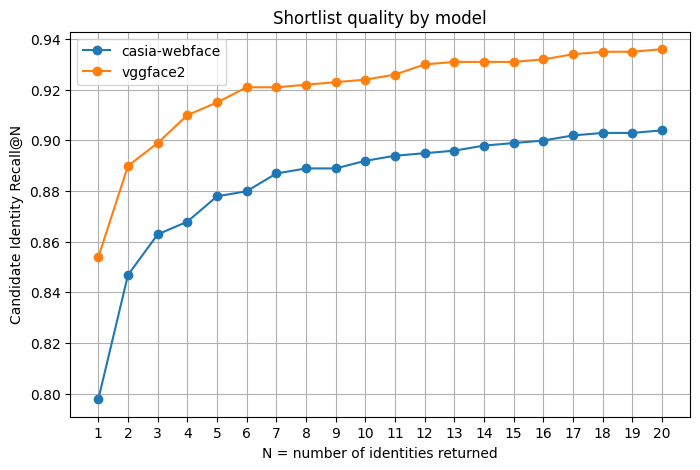

In [25]:
# Plot practical shortlist curves for the preferred methods
fig, ax = plt.subplots()
for model_name in MODEL_CONFIGS.keys():
    s = preferred_curve_df[preferred_curve_df["model"] == model_name].sort_values("N")
    ax.plot(s["N"], s["identity_recall_at_N"], marker="o", label=model_name)

ax.set_title("Shortlist quality by model")
ax.set_xlabel("N = number of identities returned")
ax.set_ylabel("Candidate Identity Recall@N")
ax.set_xticks(N_VALUES)
ax.legend()
plt.show()


## Part C: Compare Brute Force, HNSW, and LSH using the preferred method

Now we hold the **identity scoring method** fixed and ask the original indexing question: How much does the required shortlist size change when we move from exact search to HNSW or LSH?

For each model we:

1. use the preferred identity method,
2. take its Brute Force chosen shortlist size `N*`,
3. record the Brute Force recall at that point,
4. find the smallest shortlist size that HNSW and LSH need to match that target.


In [15]:
# Generic ANN evaluation for the preferred method
def evaluate_preferred_method_with_index(bundle: dict, method: str, index_name: str):
    metric = bundle["metric"]
    prb_X = bundle["prb_X"]
    prb_y = bundle["prb_y"]

    if method == "baseline_first_hit":
        X_db = bundle["gal_X"]
        metadata = bundle["gal_y"]
        index_obj, build_s = build_index(index_name, X_db, metadata, metric=metric)
        k_fetch = len(metadata) if index_name == "bruteforce" else min(ANN_K_FETCH, len(metadata))
        Qp = index_obj.query_transform(prb_X)
        t0 = time.perf_counter()
        D, I = index_obj.index.search(Qp.astype(np.float32), k_fetch)
        t1 = time.perf_counter()

        ranked_per_query = []
        true_ranks = []
        for qi in range(prb_X.shape[0]):
            ranked = ranked_identities_from_neighbors(I[qi], D[qi], index_obj.metadata, index_obj.score_mode)
            ranked_per_query.append(ranked)
            true_ranks.append(true_identity_rank(ranked, prb_y[qi]))

        curve = rank_metrics_from_true_ranks(true_ranks, N_VALUES)
        curve["ms_per_query"] = float((t1 - t0) * 1000.0 / prb_X.shape[0])
        curve["k_fetch"] = int(k_fetch)
        return {
            "curve": curve,
            "true_ranks": true_ranks,
            "ms_per_query": float((t1 - t0) * 1000.0 / prb_X.shape[0]),
            "build_seconds": build_s,
            "k_fetch": int(k_fetch),
        }

    elif method == "template_centroid":
        cent_X, cent_ids, _ = compute_identity_centroids(bundle["gal_X"], bundle["gal_y"])
        index_obj, build_s = build_index(index_name, cent_X, cent_ids, metric=metric)
        k_fetch = len(cent_ids) if index_name == "bruteforce" else min(ANN_K_FETCH, len(cent_ids))
        Qp = index_obj.query_transform(prb_X)
        t0 = time.perf_counter()
        D, I = index_obj.index.search(Qp.astype(np.float32), k_fetch)
        t1 = time.perf_counter()

        ranked_per_query = []
        true_ranks = []
        for qi in range(prb_X.shape[0]):
            ranked = ranked_identities_from_identity_index(I[qi], D[qi], index_obj.metadata, index_obj.score_mode)
            ranked_per_query.append(ranked)
            true_ranks.append(true_identity_rank(ranked, prb_y[qi]))

        curve = rank_metrics_from_true_ranks(true_ranks, N_VALUES)
        curve["ms_per_query"] = float((t1 - t0) * 1000.0 / prb_X.shape[0])
        curve["k_fetch"] = int(k_fetch)
        return {
            "curve": curve,
            "true_ranks": true_ranks,
            "ms_per_query": float((t1 - t0) * 1000.0 / prb_X.shape[0]),
            "build_seconds": build_s,
            "k_fetch": int(k_fetch),
        }
    else:
        raise ValueError(f"Unknown method={method}")


In [16]:
# ANN comparison on the preferred method
ann_curve_rows = []
ann_match_rows = []
ann_store = defaultdict(dict)

for model_name, bundle in embeddings_by_model.items():
    preferred_method = practical_n_df.loc[practical_n_df["model"] == model_name, "method"].iloc[0]
    bf_chosen_n = int(practical_n_df.loc[practical_n_df["model"] == model_name, "chosen_N"].iloc[0])

    for index_name in ["bruteforce", "hnsw", "lsh"]:
        res = evaluate_preferred_method_with_index(bundle, preferred_method, index_name)
        curve = res["curve"].copy()
        curve["model"] = model_name
        curve["method"] = preferred_method
        curve["index"] = index_name
        ann_curve_rows.append(curve)
        ann_store[model_name][index_name] = res

    ann_df_model = pd.concat([x for x in ann_curve_rows if x["model"].iloc[0] == model_name], ignore_index=True)
    bf_curve = ann_df_model[ann_df_model["index"] == "bruteforce"].sort_values("N")
    bf_target_recall = float(bf_curve.loc[bf_curve["N"] == bf_chosen_n, "identity_recall_at_N"].iloc[0])

    for index_name in ["bruteforce", "hnsw", "lsh"]:
        c = ann_df_model[ann_df_model["index"] == index_name].sort_values("N")
        matched_n = min_n_to_match_target(c, bf_target_recall, tol=MATCH_TOL)
        ann_match_rows.append({
            "model": model_name,
            "method": preferred_method,
            "index": index_name,
            "bf_reference_N": bf_chosen_n,
            "bf_target_recall": bf_target_recall,
            "matched_N": matched_n,
            "k_fetch": int(c["k_fetch"].iloc[0]),
            "ms_per_query": float(c["ms_per_query"].iloc[0]),
        })

ann_curves_df = pd.concat(ann_curve_rows, ignore_index=True)
ann_match_df = pd.DataFrame(ann_match_rows)
ann_match_df


,model,method,index,bf_reference_N,bf_target_recall,matched_N,k_fetch,ms_per_query
0,casia-webface,template_centroid,bruteforce,12,0.894895,10,999,0.111614
1,casia-webface,template_centroid,hnsw,12,0.894895,13,100,0.007860
2,casia-webface,template_centroid,lsh,12,0.894895,17,100,0.006478
3,vggface2,template_centroid,bruteforce,12,0.929930,11,999,0.108229
4,vggface2,template_centroid,hnsw,12,0.929930,11,100,0.007380
5,vggface2,template_centroid,lsh,12,0.929930,16,100,0.011124


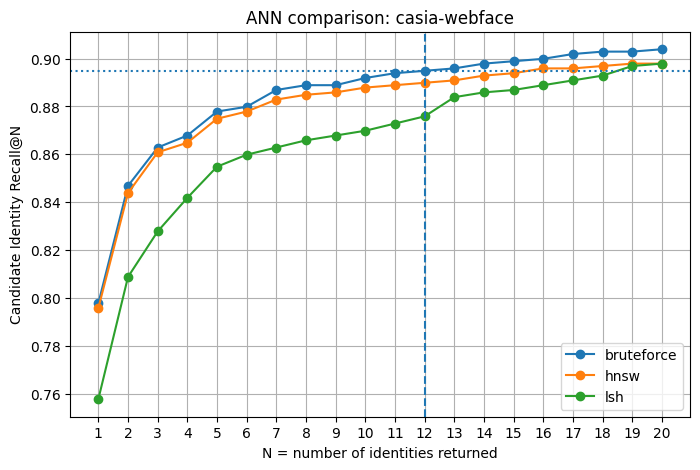

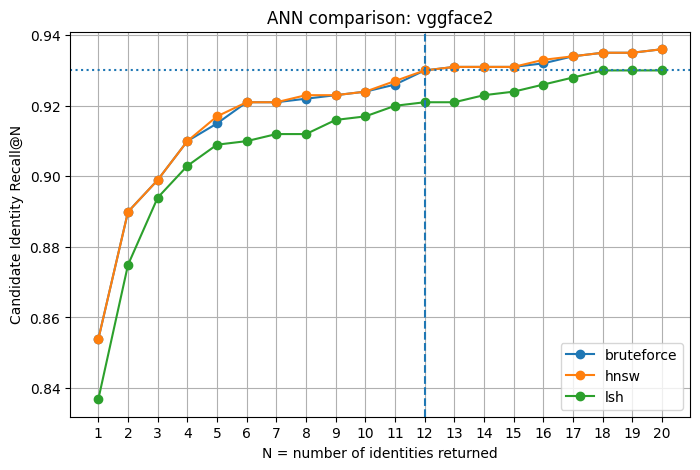

In [26]:
# Plot BF / HNSW / LSH curves for each model
for model_name in MODEL_CONFIGS.keys():
    fig, ax = plt.subplots()
    sub = ann_curves_df[ann_curves_df["model"] == model_name]
    for index_name in ["bruteforce", "hnsw", "lsh"]:
        s = sub[sub["index"] == index_name].sort_values("N")
        ax.plot(s["N"], s["identity_recall_at_N"], marker="o", label=index_name)

    bf_choice = practical_n_df.loc[practical_n_df["model"] == model_name].iloc[0]
    bf_target_n = int(bf_choice["chosen_N"])
    bf_target_recall = float(bf_choice["chosen_recall"])

    ax.axvline(bf_target_n, linestyle="--")
    ax.axhline(bf_target_recall, linestyle=":")
    ax.set_title(f"ANN comparison: {model_name}")
    ax.set_xlabel("N = number of identities returned")
    ax.set_ylabel("Candidate Identity Recall@N")
    ax.set_xticks(N_VALUES)
    ax.legend()
    plt.show()


## Part D: A simple confidence-aware output policy

This notebook does **not** perform full open-set threshold calibration.

Instead, it adds a lightweight and conceptually reasonable heuristic on top of the preferred exact method:

- compute the margin between the best and second-best identity scores,
- if the margin is large, return Top-1,
- otherwise return a small shortlist (Top-5 by default).

The threshold is chosen from the **closed-set** behavior only:

- use the `95th` percentile of margins among incorrect Top-1 cases,
- if there are no incorrect Top-1 cases, fall back to a high quantile of all margins.

This is only a practical output-design heuristic. It is **not** a substitute for full open-set calibration.


In [32]:
# Confidence-aware policy on the preferred exact method
def policy_metrics_from_result(res: dict, true_labels, fallback_k: int = FALLBACK_K):
    ranked = res["ranked"]
    true_ranks = res["true_ranks"]
    margins = np.asarray(res["margins"], dtype=float)

    top1_correct = np.asarray([(r is not None) and (r == 1) for r in true_ranks], dtype=bool)
    incorrect_margins = margins[np.isfinite(margins) & (~top1_correct)]
    all_finite = margins[np.isfinite(margins)]

    if len(incorrect_margins) > 0:
        margin_tau = float(np.quantile(incorrect_margins, INCORRECT_MARGIN_QUANTILE))
    elif len(all_finite) > 0:
        margin_tau = float(np.quantile(all_finite, FALLBACK_MARGIN_QUANTILE))
    else:
        margin_tau = 0.0

    returned_counts = []
    covered = []
    auto_top1 = []
    auto_top1_wrong = []

    for qi in range(len(true_labels)):
        m = margins[qi]
        auto = bool(np.isfinite(m) and (m >= margin_tau))
        auto_top1.append(auto)

        if auto:
            returned_counts.append(1)
            hit = bool(true_ranks[qi] == 1)
            covered.append(hit)
            auto_top1_wrong.append(not hit)
        else:
            returned_counts.append(int(fallback_k))
            r = true_ranks[qi]
            covered.append(bool((r is not None) and (r <= fallback_k)))
            auto_top1_wrong.append(False)

    return {
        "tau": margin_tau,
        "fallback_k": int(fallback_k),
        "top1": float(np.mean(auto_top1)),
        "coverage_after_policy": float(np.mean(covered)),
        "avg_returned": float(np.mean(returned_counts)),
        "review_rate": float(1.0 - np.mean(auto_top1)),
        "wrong_auto_top1_rate": float(np.mean(auto_top1_wrong)),
        "mean_margin_correct_top1": float(np.nanmean(margins[top1_correct])) if np.any(top1_correct) else np.nan,
        "mean_margin_incorrect_top1": float(np.nanmean(margins[~top1_correct])) if np.any(~top1_correct) else np.nan,
    }


policy_rows = []
for model_name in MODEL_CONFIGS.keys():
    preferred_method = practical_n_df.loc[practical_n_df["model"] == model_name, "method"].iloc[0]
    res = preferred_rankings[model_name]
    metrics = policy_metrics_from_result(res, embeddings_by_model[model_name]["prb_y"], fallback_k=min(FALLBACK_K, N_MAX))
    policy_rows.append({
        "model": model_name,
        "method": preferred_method,
        **metrics,
    })

policy_df = pd.DataFrame(policy_rows)
policy_df


,model,method,tau,fallback_k,top1,coverage_after_policy,avg_returned,review_rate,wrong_auto_top1_rate,mean_margin_correct_top1,mean_margin_incorrect_top1
0,casia-webface,template_centroid,0.082966,5,0.634635,0.870871,2.461461,0.365365,0.011011,0.164727,0.028601
1,vggface2,template_centroid,0.118136,5,0.685686,0.914915,2.257257,0.314314,0.008008,0.202907,0.036002


In [33]:
policy_df = pd.DataFrame(policy_rows).drop(columns=["method", "fallback_k"], errors="ignore")
policy_df

,model,tau,top1,coverage_after_policy,avg_returned,review_rate,wrong_auto_top1_rate,mean_margin_correct_top1,mean_margin_incorrect_top1
0,casia-webface,0.082966,0.634635,0.870871,2.461461,0.365365,0.011011,0.164727,0.028601
1,vggface2,0.118136,0.685686,0.914915,2.257257,0.314314,0.008008,0.202907,0.036002


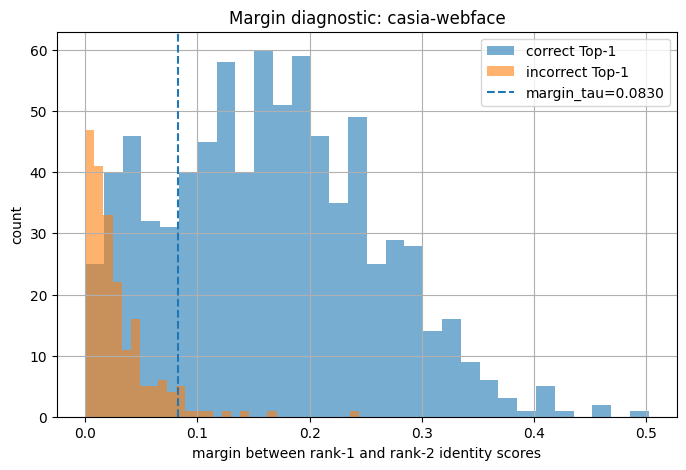

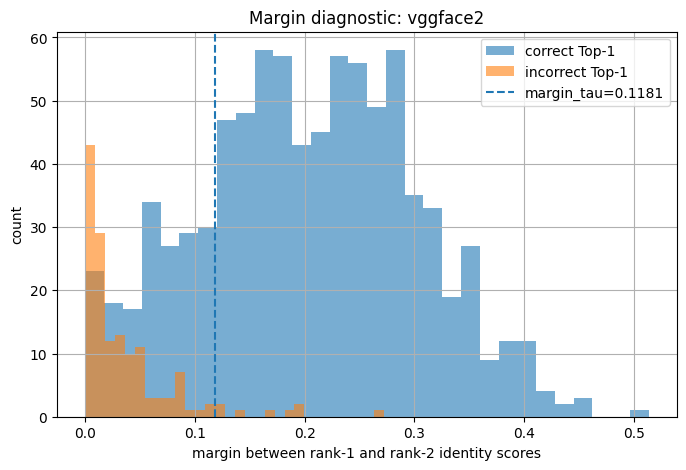

In [27]:
# Margin distributions (correct vs incorrect Top-1)
for model_name in MODEL_CONFIGS.keys():
    res = preferred_rankings[model_name]
    margins = np.asarray(res["margins"], dtype=float)
    true_ranks = np.asarray([(-1 if r is None else r) for r in res["true_ranks"]])
    correct = margins[(true_ranks == 1) & np.isfinite(margins)]
    incorrect = margins[(true_ranks != 1) & np.isfinite(margins)]

    fig, ax = plt.subplots()
    if len(correct) > 0:
        ax.hist(correct, bins=30, alpha=0.6, label="correct Top-1")
    if len(incorrect) > 0:
        ax.hist(incorrect, bins=30, alpha=0.6, label="incorrect Top-1")
    tau = float(policy_df.loc[policy_df["model"] == model_name, "margin_tau"].iloc[0])
    ax.axvline(tau, linestyle="--", label=f"margin_tau={tau:.4f}")
    ax.set_title(f"Margin diagnostic: {model_name}")
    ax.set_xlabel("margin between rank-1 and rank-2 identity scores")
    ax.set_ylabel("count")
    ax.legend()
    plt.show()


## Summary


In [20]:
def fmt_intish(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return "not reached"
    return str(int(x))


def make_report_block(model_name: str) -> str:
    chosen = practical_n_df.loc[practical_n_df["model"] == model_name].iloc[0]
    policy = policy_df.loc[policy_df["model"] == model_name].iloc[0]
    ann = ann_match_df[ann_match_df["model"] == model_name].set_index("index")

    lines = []
    lines.append(f"Model: {model_name}")
    lines.append(f"Preferred identity method: {chosen['method']}")
    lines.append(
        f"Practical shortlist N*: {int(chosen['chosen_N'])} "
        f"(Recall@N*={chosen['chosen_recall']:.4f}, peak within tested range={chosen['peak_recall']:.4f})"
    )
    lines.append(
        "Fixed-coverage shortlist sizes: "
        f"k_for_90pct={fmt_intish(chosen['k_for_90pct'])}, "
        f"k_for_95pct={fmt_intish(chosen['k_for_95pct'])}, "
        f"k_for_99pct={fmt_intish(chosen['k_for_99pct'])}"
    )
    lines.append(
        f"Index comparison against the Brute Force target at N*={int(chosen['chosen_N'])}: "
        f"BF -> {fmt_intish(ann.loc['bruteforce', 'matched_N'])}, "
        f"HNSW -> {fmt_intish(ann.loc['hnsw', 'matched_N'])}, "
        f"LSH -> {fmt_intish(ann.loc['lsh', 'matched_N'])}"
    )
    lines.append(
        f"Confidence-aware policy (Top-1 if margin >= {policy['margin_tau']:.4f}, else Top-{int(policy['fallback_k'])}) "
        f"returns on average {policy['known_avg_returned']:.2f} identities, "
        f"auto-resolves {policy['known_auto_top1']:.3f} of probes as Top-1, "
        f"and reaches coverage {policy['known_coverage_after_policy']:.4f}."
    )
    return "\n".join(lines)


for model_name in MODEL_CONFIGS.keys():
    print("=" * 88)
    print(make_report_block(model_name))
    print()


Model: casia-webface
Preferred identity method: template_centroid
Practical shortlist N*: 12 (Recall@N*=0.8949, peak within tested range=0.9039)
Fixed-coverage shortlist sizes: k_for_90pct=17, k_for_95pct=148, k_for_99pct=830
Index comparison against the Brute Force target at N*=12: BF -> 10, HNSW -> 13, LSH -> 17
Confidence-aware policy (Top-1 if margin >= 0.0830, else Top-5) returns on average 2.46 identities, auto-resolves 0.635 of probes as Top-1, and reaches coverage 0.8709.

Model: vggface2
Preferred identity method: template_centroid
Practical shortlist N*: 12 (Recall@N*=0.9299, peak within tested range=0.9359)
Fixed-coverage shortlist sizes: k_for_90pct=4, k_for_95pct=74, k_for_99pct=743
Index comparison against the Brute Force target at N*=12: BF -> 11, HNSW -> 11, LSH -> 16
Confidence-aware policy (Top-1 if margin >= 0.1181, else Top-5) returns on average 2.26 identities, auto-resolves 0.686 of probes as Top-1, and reaches coverage 0.9149.



## Save result tables

These CSV files can be reused directly in the report.


In [21]:
closed_set_summary.to_csv(OUTPUT_DIR / "closed_set_identity_method_summary.csv", index=False)
preferred_method_df.to_csv(OUTPUT_DIR / "preferred_identity_method.csv", index=False)
practical_n_df.to_csv(OUTPUT_DIR / "practical_shortlist_selection.csv", index=False)
ann_curves_df.to_csv(OUTPUT_DIR / "preferred_method_ann_curves.csv", index=False)
ann_match_df.to_csv(OUTPUT_DIR / "preferred_method_ann_match.csv", index=False)
policy_df.to_csv(OUTPUT_DIR / "confidence_aware_policy.csv", index=False)

print("Saved:")
for p in sorted(OUTPUT_DIR.glob("*.csv")):
    print(" -", p)


Saved:
 - C:\Users\Usuario\Downloads\ironclad-hortner87-main(1)\ironclad-hortner87-main\analysis\outputs_identity_output_revised\closed_set_identity_method_summary.csv
 - C:\Users\Usuario\Downloads\ironclad-hortner87-main(1)\ironclad-hortner87-main\analysis\outputs_identity_output_revised\confidence_aware_policy.csv
 - C:\Users\Usuario\Downloads\ironclad-hortner87-main(1)\ironclad-hortner87-main\analysis\outputs_identity_output_revised\practical_shortlist_selection.csv
 - C:\Users\Usuario\Downloads\ironclad-hortner87-main(1)\ironclad-hortner87-main\analysis\outputs_identity_output_revised\preferred_identity_method.csv
 - C:\Users\Usuario\Downloads\ironclad-hortner87-main(1)\ironclad-hortner87-main\analysis\outputs_identity_output_revised\preferred_method_ann_curves.csv
 - C:\Users\Usuario\Downloads\ironclad-hortner87-main(1)\ironclad-hortner87-main\analysis\outputs_identity_output_revised\preferred_method_ann_match.csv
